### Comparison between feature extractions

- Spectral flux
- Short-time energy

#### Spectral flux

In [1]:
import librosa
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

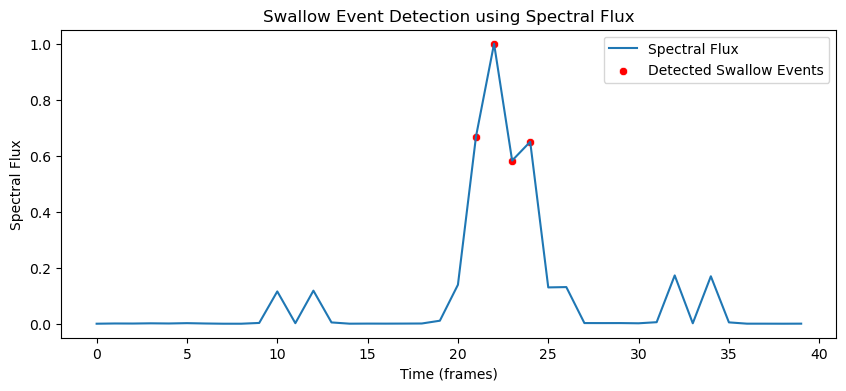

Detected swallow events at frames: [21 22 23 24]


In [15]:
def detect_swallow_event(file_path):
    # Load the audio file
    y, sr = librosa.load(file_path, sr=None)

    # Compute the Short-Time Fourier Transform (STFT)
    S = np.abs(librosa.stft(y))

    # Compute the spectral flux
    spectral_flux = np.sum(np.diff(S, axis=1) ** 2, axis=0)

    # Normalize the spectral flux
    spectral_flux /= np.max(spectral_flux)

    # Define a threshold to detect the swallow event
    threshold = 0.5

    # Detect swallow events based on the threshold
    swallow_events = np.where(spectral_flux > threshold)[0]

    # Plot the spectral flux and detected swallow events using Seaborn
    plt.figure(figsize=(10, 4))
    sns.lineplot(x=range(len(spectral_flux)), y=spectral_flux, label='Spectral Flux')
    sns.scatterplot(x=swallow_events, y=spectral_flux[swallow_events], color='red', label='Detected Swallow Events')
    plt.xlabel('Time (frames)')
    plt.ylabel('Spectral Flux')
    plt.title('Swallow Event Detection using Spectral Flux')
    plt.legend()
    plt.show()

    return swallow_events

# Example usage
file_path = r'C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GC_F1-3ml.wav' 
swallow_events = detect_swallow_event(file_path)
print("Detected swallow events at frames:", swallow_events)


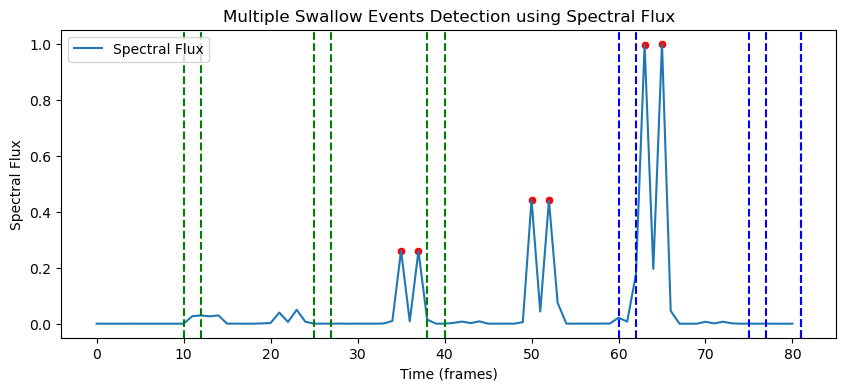

Detected swallow events at frames:
Swallow event 1: frames 10 to 60
Swallow event 2: frames 12 to 62
Swallow event 3: frames 25 to 75
Swallow event 4: frames 27 to 77
Swallow event 5: frames 38 to 81
Swallow event 6: frames 40 to 81


In [5]:
def detect_swallow_events(file_path):
    # Load the audio file
    y, sr = librosa.load(file_path, sr=None)

    # Compute the Short-Time Fourier Transform (STFT)
    S = np.abs(librosa.stft(y))

    # Compute the spectral flux
    spectral_flux = np.sum(np.diff(S, axis=1) ** 2, axis=0)

    # Normalize the spectral flux
    spectral_flux /= np.max(spectral_flux)

    # Define a threshold to detect the swallow events
    threshold = 0.25

    # Detect peaks in the spectral flux that exceed the threshold
    peaks, _ = find_peaks(spectral_flux, height=threshold)

    # Define a window size around each peak
    window_size = 50  # You can adjust this value based on your needs
    swallow_events = []

    # Plot the spectral flux and detected swallow events using Seaborn
    plt.figure(figsize=(10, 4))
    sns.lineplot(x=range(len(spectral_flux)), y=spectral_flux, label='Spectral Flux')

    for peak in peaks:
        start_frame = max(0, peak - window_size // 2)
        end_frame = min(len(spectral_flux), peak + window_size // 2)
        swallow_events.append((start_frame, end_frame))

        # Plot the delimited time frame for each swallow event
        plt.axvline(x=start_frame, color='green', linestyle='--')
        plt.axvline(x=end_frame, color='blue', linestyle='--')
        sns.scatterplot(x=[peak], y=[spectral_flux[peak]], color='red')

    plt.xlabel('Time (frames)')
    plt.ylabel('Spectral Flux')
    plt.title('Multiple Swallow Events Detection using Spectral Flux')
    plt.legend()
    plt.show()

    return swallow_events

# Example usage
file_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GC-F9-50ml.wav"
swallow_events = detect_swallow_events(file_path)
print("Detected swallow events at frames:")
for i, (start_frame, end_frame) in enumerate(swallow_events):
    print(f"Swallow event {i+1}: frames {start_frame} to {end_frame}")


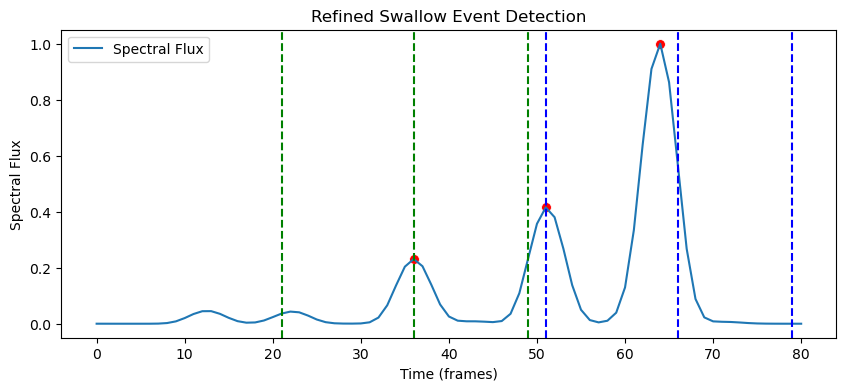

Detected swallow events at frames:
Swallow event 1: frames 21 to 51
Swallow event 2: frames 36 to 66
Swallow event 3: frames 49 to 79


In [7]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

def detect_swallow_events(file_path, threshold_factor=0.3, window_size=30):
    # Load the audio file
    y, sr = librosa.load(file_path, sr=None)

    # Compute the Short-Time Fourier Transform (STFT)
    S = np.abs(librosa.stft(y))

    # Compute the spectral flux
    spectral_flux = np.sum(np.diff(S, axis=1) ** 2, axis=0)

    # Smooth spectral flux (adjust sigma for sensitivity)
    spectral_flux = gaussian_filter1d(spectral_flux, sigma=1.5)

    # Normalize spectral flux
    spectral_flux /= np.max(spectral_flux)

    # Adaptive threshold
    threshold = np.mean(spectral_flux) + threshold_factor * np.std(spectral_flux)

    # Detect peaks with refined parameters
    peaks, _ = find_peaks(spectral_flux, height=threshold, prominence=0.05, distance=10)

    swallow_events = []

    # Plot results
    plt.figure(figsize=(10, 4))
    sns.lineplot(x=range(len(spectral_flux)), y=spectral_flux, label='Spectral Flux')

    for peak in peaks:
        start_frame = max(0, peak - window_size // 2)
        end_frame = min(len(spectral_flux), peak + window_size // 2)
        swallow_events.append((start_frame, end_frame))

        # Mark detected events
        plt.axvline(x=start_frame, color='green', linestyle='--')
        plt.axvline(x=end_frame, color='blue', linestyle='--')
        sns.scatterplot(x=[peak], y=[spectral_flux[peak]], color='red', s=50)

    plt.xlabel('Time (frames)')
    plt.ylabel('Spectral Flux')
    plt.title('Refined Swallow Event Detection')
    plt.legend()
    plt.show()

    return swallow_events

# Example usage
file_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GC-F9-50ml.wav"
swallow_events = detect_swallow_events(file_path)

# Print results
print("Detected swallow events at frames:")
for i, (start_frame, end_frame) in enumerate(swallow_events):
    print(f"Swallow event {i+1}: frames {start_frame} to {end_frame}")


____________________________________________________________________________________________________________________________________________

### Short-time Energy

### GC-F9-50ml

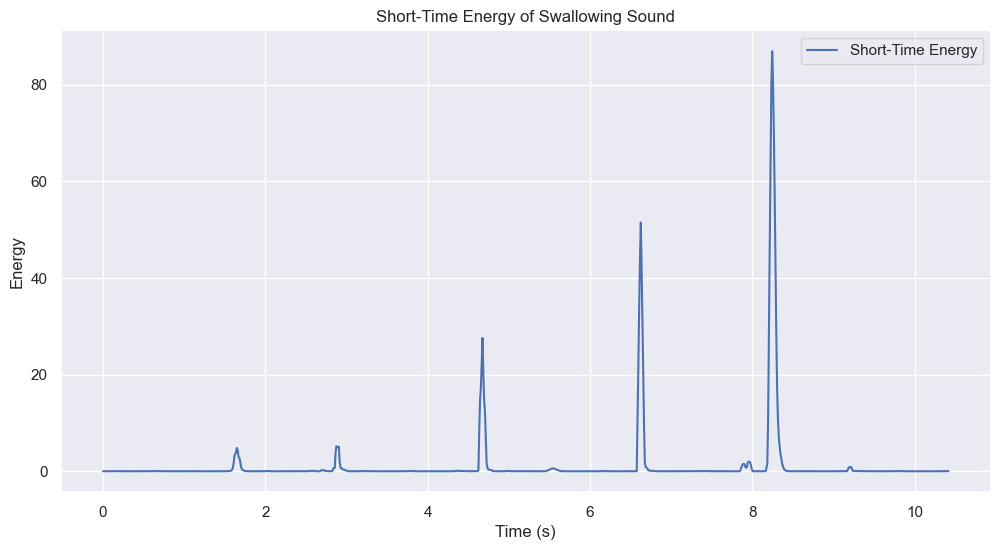

In [8]:
import numpy as np
import scipy.io.wavfile as wav
import seaborn as sns
import matplotlib.pyplot as plt

def short_time_energy(signal, frame_size, hop_size):
    energy = []
    for i in range(0, len(signal) - frame_size, hop_size):
        frame = signal[i:i + frame_size]
        energy.append(np.sum(frame ** 2))
    return np.array(energy)

# Load WAV file
file_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GC-F9-50ml.wav"
sample_rate, audio = wav.read(file_path)

# Convert to mono if stereo
if len(audio.shape) > 1:
    audio = np.mean(audio, axis=1)

# Normalize audio
audio = audio / np.max(np.abs(audio))

# Parameters
frame_size = int(0.05 * sample_rate)  # 50ms window
hop_size = int(0.01 * sample_rate)    # 10ms step

# Compute Short-Time Energy
ste = short_time_energy(audio, frame_size, hop_size)

# Plot using Seaborn
sns.set(style="darkgrid")
plt.figure(figsize=(12, 6))
time_axis = np.linspace(0, len(audio) / sample_rate, len(ste))

sns.lineplot(x=time_axis, y=ste, label="Short-Time Energy")
plt.xlabel("Time (s)")
plt.ylabel("Energy")
plt.title("Short-Time Energy of Swallowing Sound")
plt.show()


### GC-F11-50ml

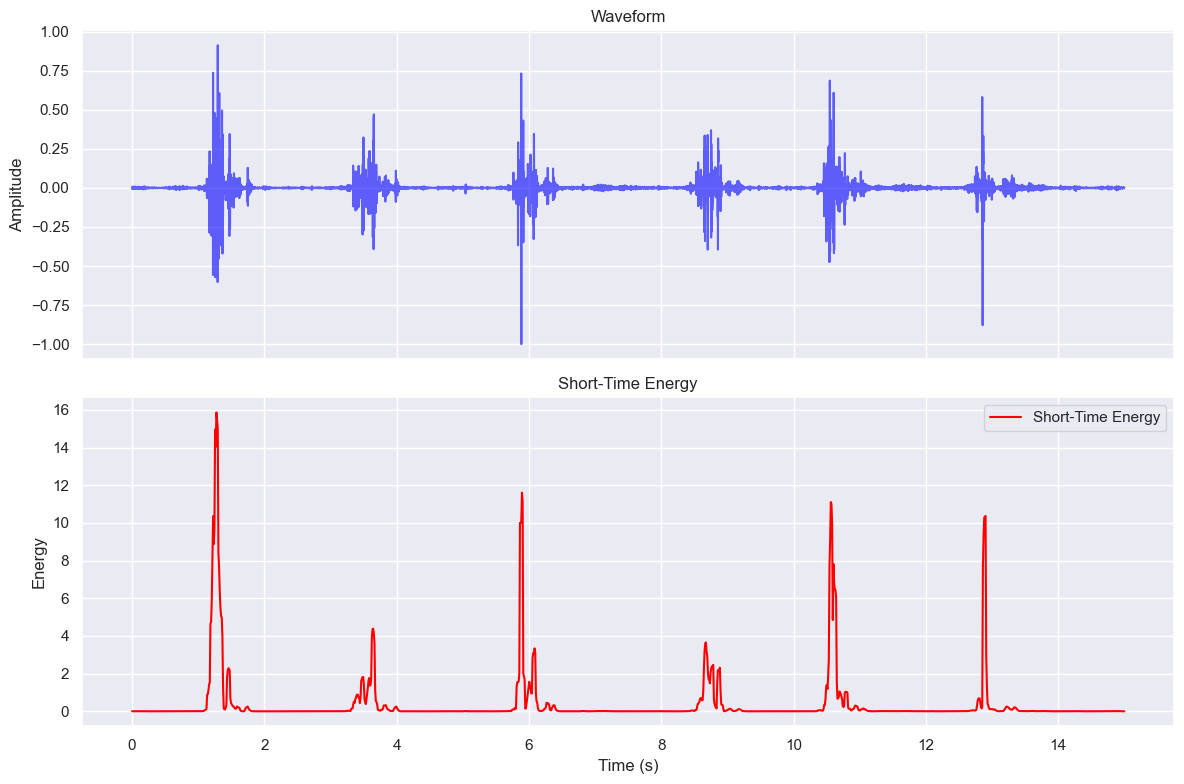

In [3]:
import numpy as np
import scipy.io.wavfile as wav
import seaborn as sns
import matplotlib.pyplot as plt

def short_time_energy(signal, frame_size, hop_size):
    energy = []
    for i in range(0, len(signal) - frame_size, hop_size):
        frame = signal[i:i + frame_size]
        energy.append(np.sum(frame ** 2))
    return np.array(energy)

# Load WAV file
file_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GC-F11-50ml.wav"
sample_rate, audio = wav.read(file_path)

# Convert to mono if stereo
if len(audio.shape) > 1:
    audio = np.mean(audio, axis=1)

# Normalize audio
audio = audio / np.max(np.abs(audio))

# Parameters
frame_size = int(0.05 * sample_rate)  # 50ms window
hop_size = int(0.01 * sample_rate)    # 10ms step

# Compute Short-Time Energy
ste = short_time_energy(audio, frame_size, hop_size)

# Time axes
time_waveform = np.linspace(0, len(audio) / sample_rate, len(audio))
time_ste = np.linspace(0, len(audio) / sample_rate, len(ste))

# Plot waveform and STE
sns.set(style="darkgrid")
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot waveform
axs[0].plot(time_waveform, audio, color='blue', alpha=0.6)
axs[0].set_title("Waveform")
axs[0].set_ylabel("Amplitude")

# Plot STE
sns.lineplot(x=time_ste, y=ste, ax=axs[1], color="red", label="Short-Time Energy")
axs[1].set_title("Short-Time Energy")
axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Energy")

plt.tight_layout()
plt.show()


Number of detected peaks: 6
Peak times (s): [ 1.27  3.63  5.87  8.64 10.52 12.85]
Swallow 1: from 0.97s to 1.57s
Swallow 2: from 3.33s to 3.93s
Swallow 3: from 5.57s to 6.17s
Swallow 4: from 8.34s to 8.94s
Swallow 5: from 10.22s to 10.82s
Swallow 6: from 12.55s to 13.15s


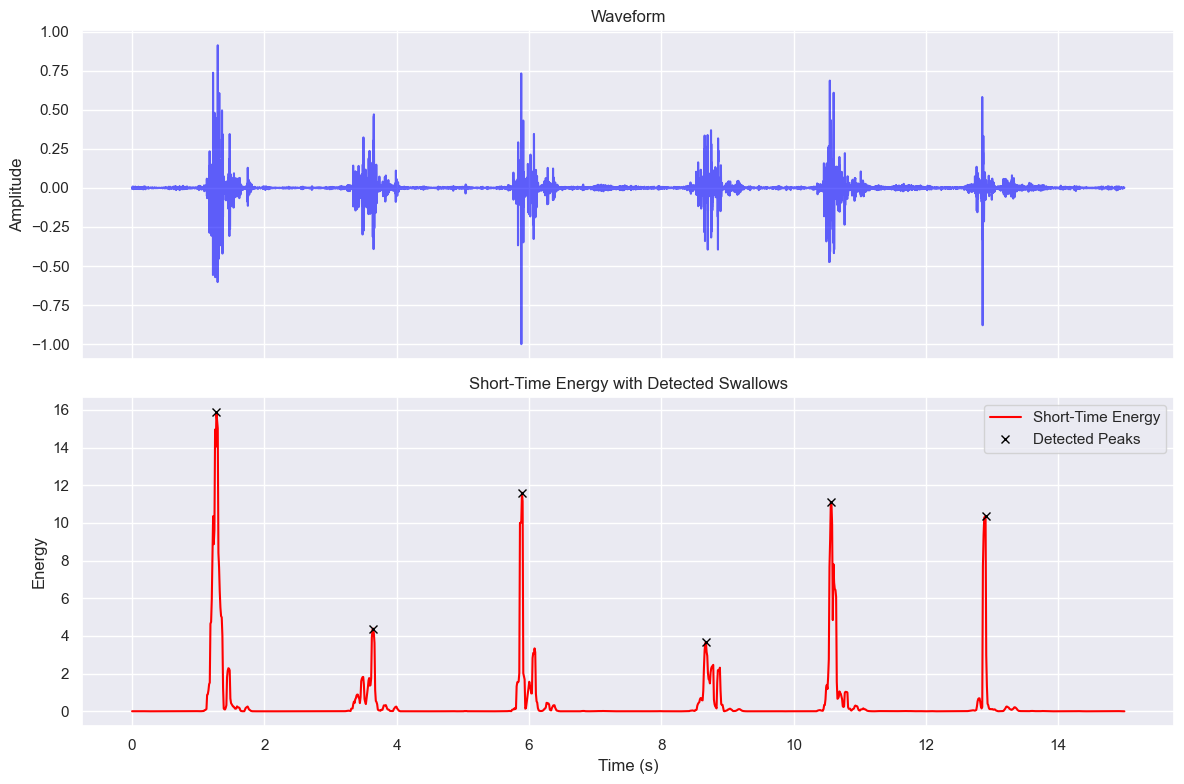

In [ ]:
import numpy as np
import pandas as pd
import scipy.io.wavfile as wav
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def short_time_energy(signal, frame_size, hop_size):
    """
    Compute Short-Time Energy (STE) of the input signal.
    """
    energy = []
    for i in range(0, len(signal) - frame_size, hop_size):
        frame = signal[i : i + frame_size]
        energy.append(np.sum(frame ** 2))
    return np.array(energy)

# -------------------
# 1. Load and Preprocess
# -------------------
file_path =  r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GC-F11-50ml.wav"
sample_rate, audio = wav.read(file_path)

# If stereo, convert to mono
if len(audio.shape) > 1:
    audio = np.mean(audio, axis=1)

# Normalize
audio = audio / np.max(np.abs(audio))

# -------------------
# 2. Compute STE criar dataframe para guardar o hop_size e frame_size
# -------------------
frame_duration = 0.05  # 50 ms
hop_duration = 0.01    # 10 ms

frame_size = int(frame_duration * sample_rate)
hop_size = int(hop_duration * sample_rate)

ste = short_time_energy(audio, frame_size, hop_size)

# Time axes for plotting
time_waveform = np.linspace(0, len(audio) / sample_rate, len(audio))
time_ste = np.linspace(0, len(audio) / sample_rate, len(ste))

# -------------------
# 3. Detect Peaks in STE
# -------------------
# A. Dynamic threshold: alterei de 2.5 para 1.5 para detetar um pico com menos energ
threshold = np.mean(ste) + 1.5 * np.std(ste)

# B. Minimum distance between peaks (in samples of the STE signal)
#    e.g. 0.5 seconds between swallows -> 0.5 / hop_duration
min_distance = int(0.5 / hop_duration)

# C. Optionally, set a minimum prominence (how "tall" a peak is relative to surroundings)
#    If you find 'threshold' alone insufficient, you can also use 'prominence'.
peaks, properties = find_peaks(
    ste,
    height=threshold,
    distance=min_distance,
    # prominence=some_value,   # e.g. 0.1, 0.5, etc., if needed
)

# Convert peak indices to time in seconds
peak_times = peaks * hop_duration

print(f"Number of detected peaks: {len(peaks)}")
print("Peak times (s):", peak_times)

# -------------------
# 4. Print Time Windows
# -------------------
# If you want to define a time window around each peak and print that:
window_len = 0.3  # e.g., +/- 0.3s around each detected peak
for i, peak_time in enumerate(peak_times):
    start_time = peak_time - window_len
    end_time   = peak_time + window_len
    # Ensure they don't go below 0 or above total duration
    start_time = max(start_time, 0.0)
    end_time   = min(end_time, len(audio)/sample_rate)
    
    print(f"Swallow {i+1}: from {start_time:.2f}s to {end_time:.2f}s")

# -------------------
# 5. Plot Waveform & STE with Detected Peaks
# -------------------
sns.set(style="darkgrid")
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot raw waveform
axs[0].plot(time_waveform, audio, color='blue', alpha=0.6)
axs[0].set_title("Waveform")
axs[0].set_ylabel("Amplitude")

# Plot STE
axs[1].plot(time_ste, ste, color='red', label="Short-Time Energy")
axs[1].plot(time_ste[peaks], ste[peaks], "x", color='black', label="Detected Peaks")
axs[1].set_title("Short-Time Energy with Detected Swallows")
axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel("Energy")
axs[1].legend()

plt.tight_layout()
plt.show()